<a href="https://colab.research.google.com/github/Danis1402/1P---Danis-Gonz-lez/blob/main/Semana_03/Ejercicio/datos/Preprocesamiento.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

🔍 Encontrados 3 archivos para procesar:
  • rendimiento_año_2024_ciclo_2_anon.xlsx
  • rendimiento_año_2025_ciclo_1_anon.xlsx
  • rendimiento_año_2025_ciclo_2_anon.xlsx
--------------------------------------------------
📄 Procesando archivo 1/3: rendimiento_año_2025_ciclo_1_anon.xlsx
   ✅ Registros cargados: 19,407
📄 Procesando archivo 2/3: rendimiento_año_2024_ciclo_2_anon.xlsx
   ✅ Registros cargados: 24,468
📄 Procesando archivo 3/3: rendimiento_año_2025_ciclo_2_anon.xlsx
   ✅ Registros cargados: 20,420

✅ Total de registros concatenados: 64,295
📊 ANÁLISIS DESCRIPTIVO GENERAL DE LOS DATOS

1. INFORMACIÓN BÁSICA DEL DATASET
📌 Total de registros: 64,295
📌 Total de columnas: 30
📌 Total de estudiantes únicos: 4,759
📌 Total de asignaturas únicas: 326
📌 Rango de años: 2024 - 2025
📌 Semestres/Ciclos disponibles: [np.int64(1), np.int64(2)]

2. ESTRUCTURA DE LOS DATOS

📋 Primeras 5 filas:


,ALUMNO_ID,Cod.Asign,Asignatura,Cod.Car.Sec,Cod.Curso,Convocatoria,Anho,Semestre,Doc.Firma,Aprobado,Anho.Firma,Primer.Par,Segundo.Par,Tercer.Par,TPLab.,Lab.,Proy.,Pond.PP,Pond.SP,Pond.TPLab,Pond.Lab,Pond.Proy,Asis,Requisito,Firma,Primer.Rec,Segundo.Rec,Nota.Final,FirmaCalculada,Archivo_Origen
0,FIUNA_ALUMNO_005168,13016,FISICA 4,IND-PLS13,4,1,2025,1,0,N,0,44,35,0,0,100,0,45,45,0,10,0,0,0,0.0,0,0,NaN,46.0,rendimiento_año_2025_ciclo_1_anon.xlsx
1,FIUNA_ALUMNO_007802,13016,FISICA 4,IND-PLS13,4,1,2025,1,0,N,0,44,35,0,0,100,0,45,45,0,10,0,0,0,0.0,0,0,NaN,46.0,rendimiento_año_2025_ciclo_1_anon.xlsx
2,FIUNA_ALUMNO_005236,13016,FISICA 4,CIV-PLS13,4,1,2025,1,36484,N,2024,0,0,0,0,100,0,45,45,0,10,0,1,1,37.0,0,0,NaN,10.0,rendimiento_año_2025_ciclo_1_anon.xlsx
3,FIUNA_ALUMNO_007824,13016,FISICA 4,CIV-PLS13,4,1,2025,1,36484,N,2024,0,0,0,0,100,0,45,45,0,10,0,1,1,37.0,0,0,NaN,10.0,rendimiento_año_2025_ciclo_1_anon.xlsx
4,FIUNA_ALUMNO_005531,13016,FISICA 4,CIV-PLS13,4,1,2025,1,0,N,0,0,0,0,0,92,0,45,45,0,10,0,2,1,0.0,0,0,NaN,9.0,rendimiento_año_2025_ciclo_1_anon.xlsx



🔍 Columnas con datos faltantes (2 columnas):


,Missing_Count,Missing_Percent
FirmaCalculada,44888,69.815693
Nota.Final,21575,33.556264



📈 VISUALIZACIONES DE DATOS


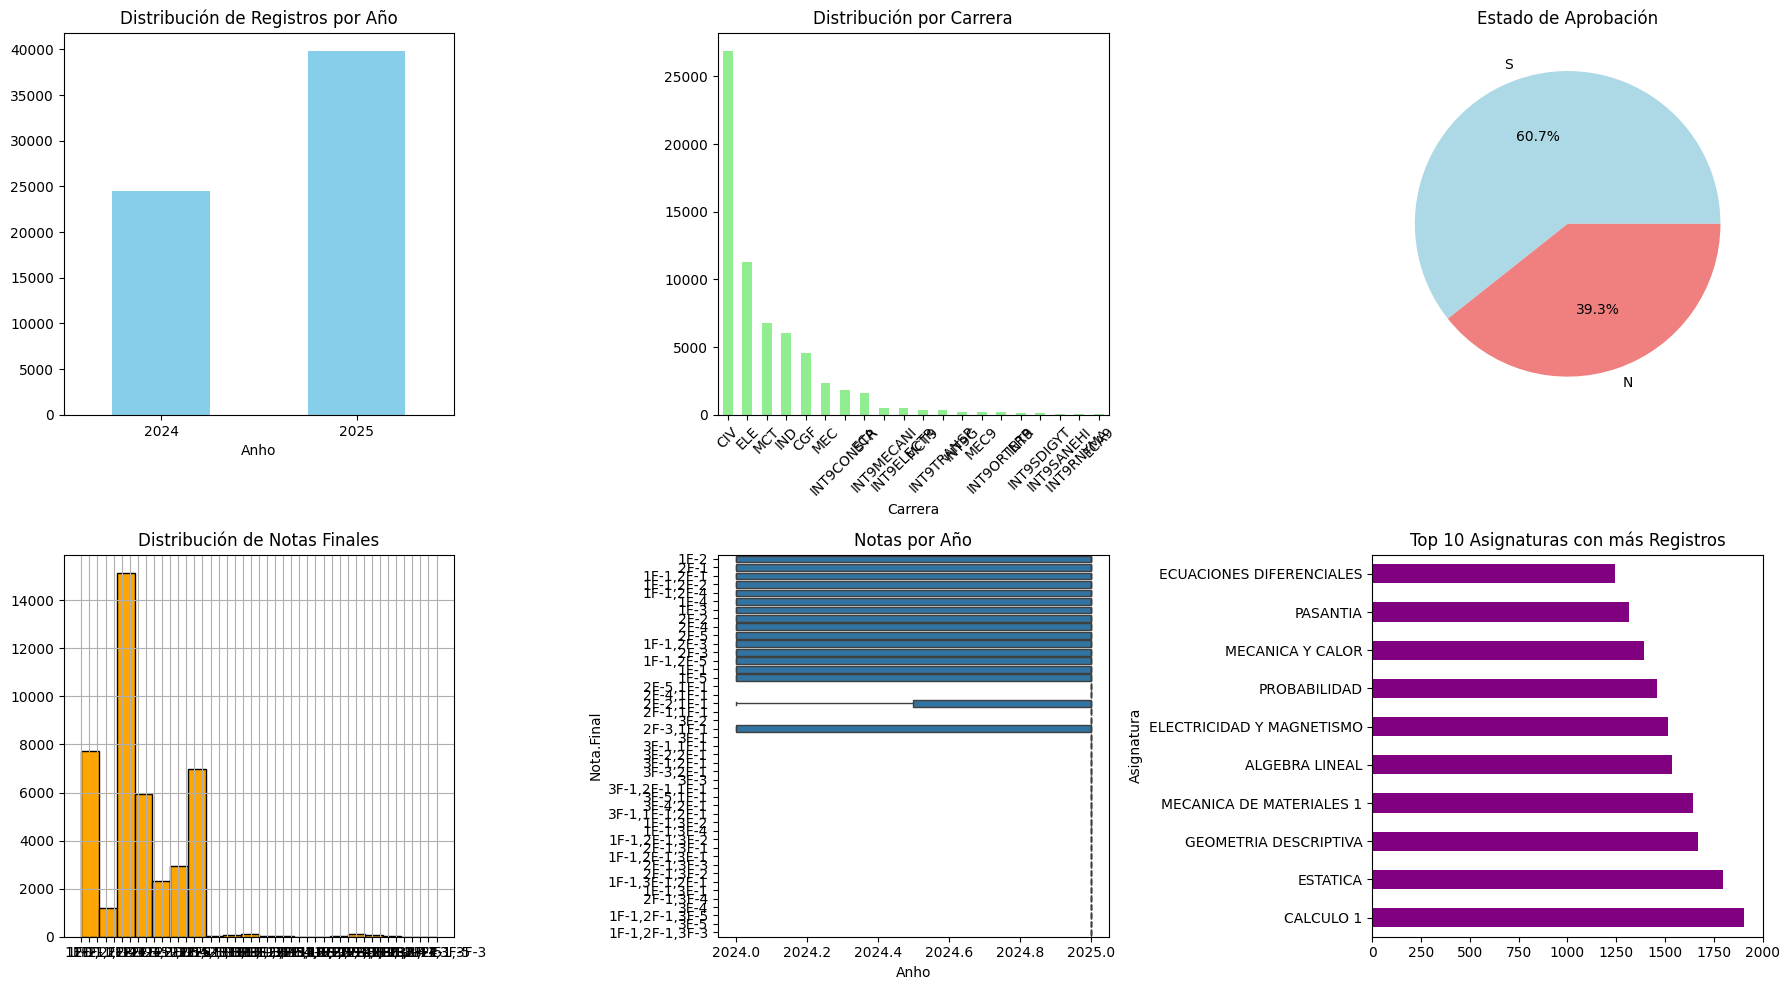


✅ Proceso completado. Datos concatenados guardados en '/content/datos_concatenados.csv'
⬇️ Iniciando descarga automática del archivo 'datos_concatenados.csv'...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
import os
import re
from google.colab import files  # Import para la descarga automática

# Configuración de pantalla para Pandas
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.width', None)

# =============================================================================
# 1. CARGA Y CONCATENACIÓN DE DATOS (OPCIÓN B: DETECCIÓN AUTOMÁTICA)
# =============================================================================

def cargar_y_concatenar(PATH, files_list):
    """
    Carga y concatena automáticamente los archivos coincidentes en el directorio.
    """
    lista_dfs = []

    for i, filename in enumerate(files_list, 1):
        print(f"📄 Procesando archivo {i}/{len(files_list)}: {filename}")

        try:
            ruta_completa = os.path.join(PATH, filename)
            # Se omite sheet_name para tomar automáticamente la primera pestaña
            lectura = pd.read_excel(ruta_completa)

            # Extraer año (4 dígitos) y ciclo/semestre (1 dígito después de 'ciclo_')
            match_anho = re.search(r'(19|20)\d{2}', filename)
            match_semestre = re.search(r'ciclo_(\d)', filename, re.IGNORECASE)

            lectura['Anho'] = int(match_anho.group(0)) if match_anho else np.nan
            lectura['Semestre'] = int(match_semestre.group(1)) if match_semestre else np.nan
            lectura['Archivo_Origen'] = filename

            lista_dfs.append(lectura)
            print(f"   ✅ Registros cargados: {len(lectura):,}")

        except Exception as e:
            print(f"   ❌ Error al procesar {filename}: {e}")

    if lista_dfs:
        datos_concatenados = pd.concat(lista_dfs, axis=0, ignore_index=True)
        print(f"\n✅ Total de registros concatenados: {len(datos_concatenados):,}")
        return datos_concatenados
    else:
        return pd.DataFrame()

# =============================================================================
# 2. ANÁLISIS DESCRIPTIVO GENERAL
# =============================================================================

def analisis_descriptivo_general(df):
    print("="*80)
    print("📊 ANÁLISIS DESCRIPTIVO GENERAL DE LOS DATOS")
    print("="*80)

    print("\n1. INFORMACIÓN BÁSICA DEL DATASET")
    print(f"📌 Total de registros: {len(df):,}")
    print(f"📌 Total de columnas: {len(df.columns)}")

    if 'ALUMNO_ID' in df.columns:
        print(f"📌 Total de estudiantes únicos: {df['ALUMNO_ID'].nunique():,}")
    if 'Asignatura' in df.columns:
        print(f"📌 Total de asignaturas únicas: {df['Asignatura'].nunique():,}")
    if 'Anho' in df.columns:
        print(f"📌 Rango de años: {df['Anho'].min()} - {df['Anho'].max()}")
    if 'Semestre' in df.columns:
        print(f"📌 Semestres/Ciclos disponibles: {sorted(df['Semestre'].dropna().unique())}")

    print("\n2. ESTRUCTURA DE LOS DATOS")
    print("\n📋 Primeras 5 filas:")
    display(df.head())

    # Análisis de datos faltantes
    missing_data = df.isnull().sum()
    missing_percent = (missing_data / len(df)) * 100
    missing_df = pd.DataFrame({'Missing_Count': missing_data, 'Missing_Percent': missing_percent})
    missing_df = missing_df[missing_df['Missing_Count'] > 0].sort_values('Missing_Count', ascending=False)

    if len(missing_df) > 0:
        print(f"\n🔍 Columnas con datos faltantes ({len(missing_df)} columnas):")
        display(missing_df)
    else:
        print("\n✅ No hay datos faltantes en el dataset")

    carreras_counts = None
    aprobacion_counts = None

    if 'Cod.Car.Sec' in df.columns:
        df['Carrera'] = df['Cod.Car.Sec'].astype(str).str.split('-').str[0]
        carreras_counts = df['Carrera'].value_counts()

    if 'Aprobado' in df.columns:
        aprobacion_counts = df['Aprobado'].value_counts()

    return {
        'missing_data': missing_df,
        'carreras_counts': carreras_counts,
        'aprobacion_counts': aprobacion_counts
    }

# =============================================================================
# 3. VISUALIZACIONES
# =============================================================================

def visualizar_datos(df):
    print("\n" + "="*80)
    print("📈 VISUALIZACIONES DE DATOS")
    print("="*80)

    fig, axes = plt.subplots(2, 3, figsize=(18, 10))

    # 1. Distribución por año
    if 'Anho' in df.columns:
        df['Anho'].value_counts().sort_index().plot(kind='bar', ax=axes[0,0], color='skyblue')
        axes[0,0].set_title('Distribución de Registros por Año')
        axes[0,0].tick_params(axis='x', rotation=0)

    # 2. Distribución por carrera
    if 'Carrera' in df.columns:
        df['Carrera'].value_counts().plot(kind='bar', ax=axes[0,1], color='lightgreen')
        axes[0,1].set_title('Distribución por Carrera')
        axes[0,1].tick_params(axis='x', rotation=45)

    # 3. Estado de aprobación
    if 'Aprobado' in df.columns:
        df['Aprobado'].value_counts().plot(kind='pie', ax=axes[0,2], autopct='%1.1f%%', colors=['lightblue', 'lightcoral'])
        axes[0,2].set_title('Estado de Aprobación')
        axes[0,2].set_ylabel('')

    # 4. Distribución de notas
    if 'Nota.Final' in df.columns:
        df['Nota.Final'].dropna().hist(bins=20, ax=axes[1,0], color='orange', edgecolor='black')
        axes[1,0].set_title('Distribución de Notas Finales')

    # 5. Nota por año
    if 'Nota.Final' in df.columns and 'Anho' in df.columns:
        sns.boxplot(x='Anho', y='Nota.Final', data=df, ax=axes[1,1])
        axes[1,1].set_title('Notas por Año')

    # 6. Top 10 asignaturas
    if 'Asignatura' in df.columns:
        df['Asignatura'].value_counts().head(10).plot(kind='barh', ax=axes[1,2], color='purple')
        axes[1,2].set_title('Top 10 Asignaturas con más Registros')

    plt.tight_layout()
    plt.show()

# =============================================================================
# 4. EJECUCIÓN PRINCIPAL
# =============================================================================

def main():
    PATH = "/content"

    # Buscar todos los archivos Excel en /content/ que comiencen por "rendimiento_"
    found_files = [f for f in os.listdir(PATH) if f.startswith("rendimiento_") and f.endswith(('.xls', '.xlsx'))]

    if not found_files:
        print("❌ No se encontraron archivos 'rendimiento_*.xlsx' en /content/")
        return

    print(f"🔍 Encontrados {len(found_files)} archivos para procesar:")
    for f in sorted(found_files):
        print(f"  • {f}")
    print("-" * 50)

    # 1. Cargar y concatenar datos
    datos = cargar_y_concatenar(PATH, found_files)

    if datos.empty:
        print("❌ No se pudieron cargar los datos.")
        return

    # 2. Análisis y gráficos
    resultados = analisis_descriptivo_general(datos)
    visualizar_datos(datos)

    # 3. Guardar el archivo consolidado
    ruta_salida = "/content/datos_concatenados.csv"
    datos.to_csv(ruta_salida, index=False)
    print("\n✅ Proceso completado. Datos concatenados guardados en '/content/datos_concatenados.csv'")

    # 4. Descarga automática en Google Colab
    print("⬇️ Iniciando descarga automática del archivo 'datos_concatenados.csv'...")
    files.download(ruta_salida)

    return datos, resultados

# =============================================================================
# EJECUTAR EL ANÁLISIS
# =============================================================================

if __name__ == "__main__":
    datos_procesados, resultados_analisis = main()